# Notebook 02: Baseline Machine Learning Models

**Project 3.1: Heart Disease Diagnosis Using Machine Learning**  
AI VIET NAM – AI Course 2026 (Part 1 Experiments)

---
### Objectives:
1. Train & evaluate **Gaussian Naive Bayes** on Original vs. FE datasets.
2. Optimize $K$ for **K-Nearest Neighbors (KNN)** using Stratified 5-Fold Cross-Validation.
3. Optimize `max_depth` for **Decision Tree** and inspect feature importances.
4. Implement **K-Means Unsupervised Clustering** with $k=2$ and majority class mapping.
5. Build a **Stacking Classifier** combining KNN, Decision Tree, and Naive Bayes.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))
from src.config import SEED
from src.models.base_models import (
    GaussianNBModel,
    KNNModel,
    DecisionTreeModel,
    KMeansClassifierModel,
    StackingEnsembleModel
)
from src.evaluation.metrics import print_classification_summary
from src.evaluation.visualization import plot_comparison_bar_chart

print("[✓] Baseline environment loaded.")

[✓] Baseline environment loaded.


## 1. Load Preprocessed Dataset Splits

Load `raw_train.csv`, `raw_val.csv`, `raw_test.csv`, and `fe_train.csv`, `fe_val.csv`, `fe_test.csv`.

In [2]:
# TODO: Load CSV splits into X_train, y_train, X_val, y_val, X_test, y_test for both raw and fe configurations
splits = Path("../data/splits")
def load_split(file_path):
    df = pd.read_csv(file_path)
    X = df.drop(columns=["target"])
    y = df["target"]
    return X,y

# 1. Original (Raw) Splits
X_train, y_train = load_split(splits / "raw_train.csv")
X_val, y_val     = load_split(splits / "raw_val.csv")
X_test, y_test   = load_split(splits / "raw_test.csv")
# 2. Feature Engineering (FE) Splits
X_train_fe, y_train_fe = load_split(splits / "fe_train.csv")
X_val_fe, y_val_fe     = load_split(splits / "fe_val.csv")
X_test_fe, y_test_fe   = load_split(splits / "fe_test.csv")
print(f"[✓] Original train shape: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")
print(f"[✓] FE train shape:       {X_train_fe.shape}, val: {X_val_fe.shape}, test: {X_test_fe.shape}")

[✓] Original train shape: (242, 13), val: (30, 13), test: (31, 13)
[✓] FE train shape:       (242, 17), val: (30, 17), test: (31, 17)


## 2. Gaussian Naive Bayes Experiment

**TODO:**
- Fit `GaussianNBModel` on `raw_train` and evaluate on `raw_val` & `raw_test`.
- Fit on `fe_train` and evaluate on `fe_val` & `fe_test`.
- Compare performance using `plot_comparison_bar_chart`.

In [3]:
%load_ext autoreload
%autoreload 2



[+] Performance on original validation Split:
    Accuracy: 0.9000

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.81      0.90        16
           1       0.82      1.00      0.90        14

    accuracy                           0.90        30
   macro avg       0.91      0.91      0.90        30
weighted avg       0.92      0.90      0.90        30


[+] Performance on original test Split:
    Accuracy: 0.8387

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.76      0.84        17
           1       0.76      0.93      0.84        14

    accuracy                           0.84        31
   macro avg       0.85      0.85      0.84        31
weighted avg       0.85      0.84      0.84        31


[+] Performance on FE Validation Split:
    Accuracy: 0.8333

--- Classification Report ---
              precision    recall  f1-score   support

      

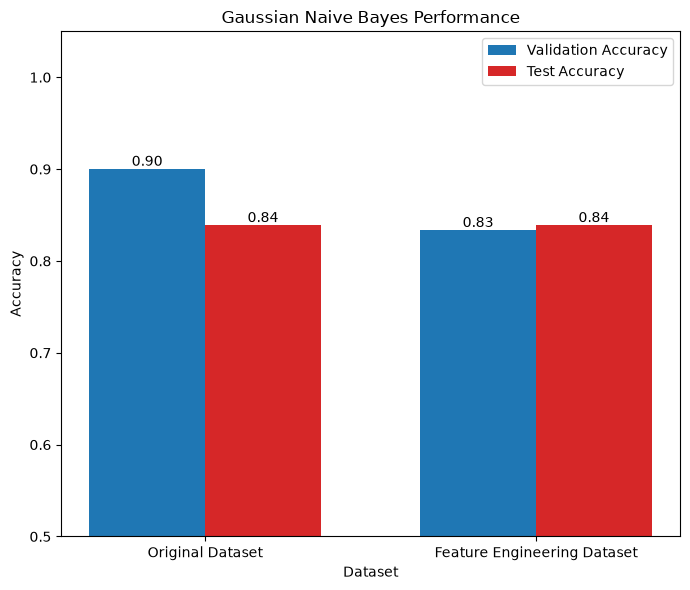

In [4]:
# TODO: Train and evaluate Gaussian Naive Bayes
from src.models.base_models import GaussianNBModel

gaussian_naive_bayes_raw = GaussianNBModel()
gaussian_naive_bayes_raw.fit(X_train, y_train)

val_pred_raw = gaussian_naive_bayes_raw.predict(X_val)
test_pred_raw = gaussian_naive_bayes_raw.predict(X_test)

val_acc_raw = print_classification_summary("original validation", y_val, val_pred_raw)
test_acc_raw =  print_classification_summary("original test", y_test, test_pred_raw)

nb_fe = GaussianNBModel()
nb_fe.fit(X_train_fe, y_train_fe)
val_pred_fe = nb_fe.predict(X_val_fe)
test_pred_fe = nb_fe.predict(X_test_fe)
val_acc_fe = print_classification_summary("FE Validation", y_val_fe, val_pred_fe)
test_acc_fe = print_classification_summary("FE Test", y_test_fe, test_pred_fe)

plot_comparison_bar_chart(
    dataset_labels=["Original Dataset", "Feature Engineering Dataset"],
    val_accuracies=[val_acc_raw, val_acc_fe],
    test_accuracies=[test_acc_raw, test_acc_fe],
    model_name="Gaussian Naive Bayes Performance"
)


## 3. K-Nearest Neighbors (KNN) Tuning & Evaluation

**TODO:**
- Search for optimal $K \in [1, 20]$ using `KNNModel.find_optimal_k` via Stratified 5-Fold CV.
- Plot CV Accuracy curve.
- Fit KNN model with best $K$ and evaluate on Val/Test sets.


[+] Performance on original validation Split:
    Accuracy: 0.9333

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.88      0.93        16
           1       0.88      1.00      0.93        14

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.93        30
weighted avg       0.94      0.93      0.93        30


[+] Performance on original test Split:
    Accuracy: 0.8387

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.88      0.86        17
           1       0.85      0.79      0.81        14

    accuracy                           0.84        31
   macro avg       0.84      0.83      0.84        31
weighted avg       0.84      0.84      0.84        31


[+] Performance on FE Validation Split:
    Accuracy: 0.8333

--- Classification Report ---
              precision    recall  f1-score   support

      

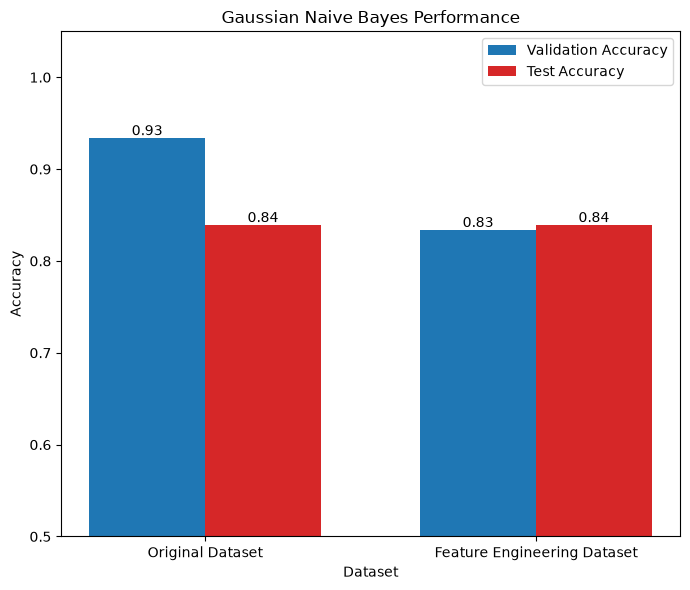

In [ ]:
from src.models.base_models import KNNModel

kn_raw = KNNModel()
kn_raw.fit(X_train,y_train)

pred_kn_raw = kn_raw.predict(X_val)
pred_kn_test = kn_raw.predict(X_test)
kn_acc_raw = print_classification_summary("original validation", y_val, pred_kn_raw)
kn_acc_test = print_classification_summary("original test", y_test, pred_kn_test)

kn_fe = GaussianNBModel()
kn_fe.fit(X_train_fe, y_train_fe)
pred_kn_fe = kn_fe.predict(X_val_fe)
pred_kn_fe_test = kn_fe.predict(X_test_fe)
kn_acc_fe = print_classification_summary("FE Validation", y_val_fe, pred_kn_fe)
kn_acc_fe_test = print_classification_summary("FE Test", y_test_fe, pred_kn_fe_test)

plot_comparison_bar_chart(
    dataset_labels=["Original Dataset", "Feature Engineering Dataset"],
    val_accuracies=[kn_acc_raw, kn_acc_fe],
    test_accuracies=[kn_acc_test, kn_acc_fe_test],
    model_name="Gaussian Naive Bayes Performance"
)

## 4. Decision Tree Tuning & Feature Importance

**TODO:**
- Search for optimal `max_depth \in [2, 10]` using `DecisionTreeModel.find_optimal_depth`.
- Extract Gini feature importances and display top 10 most influential predictors.

In [19]:
# TODO: Run Decision Tree depth search and plot feature importances
from src.models.base_models import DecisionTreeModel
dt = DecisionTreeModel()
best_depth, score_ls = dt.find_optimal_depth(X_train,y_train)
dt.fit(X_train,y_train,max_depth=best_depth)
pred_dt_raw = dt.predict(X_val)
pred_dt_test = dt.predict(X_test)

importance_feat = dt.get_feature_importances()

dt_acc_raw = print_classification_summary("original validation", y_val, pred_dt_raw)
dt_acc_test = print_classification_summary("original test", y_test, pred_dt_test)
print(importance_feat)


[+] Performance on original validation Split:
    Accuracy: 0.9333

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       0.93      0.93      0.93        14

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


[+] Performance on original test Split:
    Accuracy: 0.8065

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        17
           1       0.79      0.79      0.79        14

    accuracy                           0.81        31
   macro avg       0.80      0.80      0.80        31
weighted avg       0.81      0.81      0.81        31

thal        0.536927
cp          0.194140
ca          0.168773
oldpeak     0.066853
age         0.033307
thalach     0.000000
chol        0.000000
trestbp

## 5. K-Means Unsupervised Classification

**TODO:**
- Cluster training data into $k=2$ clusters.
- Map cluster indices to target labels using training majority class mode.
- Predict and evaluate on Validation and Test sets.

In [7]:
# TODO: Fit and test KMeansClassifierModel

## 6. Stacking Ensemble Classifier

**TODO:**
- Combine KNN, Decision Tree, and Naive Bayes with a KNN Meta-Classifier.
- Evaluate on both Original and FE datasets.

In [8]:
# TODO: Fit and evaluate StackingEnsembleModel